# A/B Test Simulation

This notebook simulates an A/B test running day-by-day, tracking the p-value and group means over time.

**Two scenarios are explored:**
1. A real effect exists (experiment group has a slightly higher mean)
2. No effect exists (both groups have identical distributions)

In [67]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
%matplotlib inline

## Scenario 1: Real Effect (μ_experiment > μ_control)

The experiment group has a slightly higher mean (100.5 vs 100).
We run the test for 10 days and observe how the p-value evolves.

> Try varying the effect size (e.g., μ_experiment = 102 or 105) or increasing the sample size to see how that affects detection speed.

In [68]:
days = 10

mu_control,    sigma_control,    n_control    = 100,   20, 100
mu_experiment, sigma_experiment, n_experiment = 100.5, 20, 100

In [69]:
current_date = 1
user_data    = pd.DataFrame()
stat_result  = pd.DataFrame()
daily_data   = pd.DataFrame()

for day in range(days):
    # Simulate daily observations for each group
    daily_data_control    = np.random.normal(mu_control,    sigma_control,    n_control)
    daily_data_experiment = np.random.normal(mu_experiment, sigma_experiment, n_experiment)

    day_data_control              = pd.DataFrame({'value': daily_data_control})
    day_data_control['date']      = current_date
    day_data_control['group']     = 'control'

    day_data_experiment            = pd.DataFrame({'value': daily_data_experiment})
    day_data_experiment['date']    = current_date
    day_data_experiment['group']   = 'experiment'

    # Accumulate all data so far (cumulative test)
    user_data = pd.concat([user_data, day_data_control, day_data_experiment], ignore_index=True)

    # Run t-test on all accumulated data
    fit = stats.ttest_ind(
        user_data[user_data.group == 'control'].value,
        user_data[user_data.group == 'experiment'].value
    )
    stat_result = pd.concat([
        stat_result,
        pd.DataFrame({'t': [fit[0]], 'p': [fit[1]], 'date': current_date})
    ])

    # Track daily cumulative means per group
    current_data_stat          = user_data.groupby('group').agg({'value': 'mean'})
    current_data_stat['date']  = current_date
    daily_data = pd.concat([daily_data, current_data_stat])

    current_date += 1

Text(0.5, 1.0, 'Scenario 1: Cumulative Mean by Group')

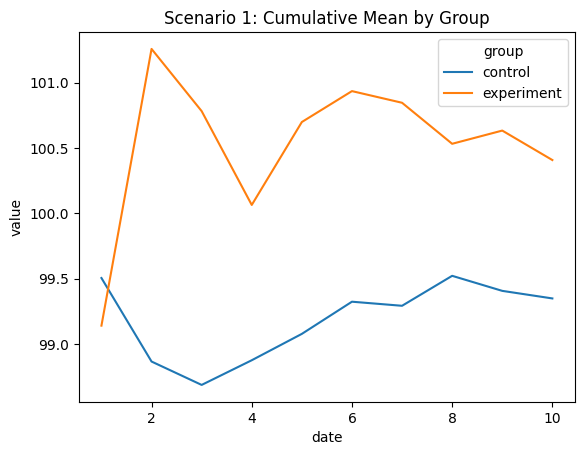

In [70]:
# Cumulative mean value per group over time
ax = sns.lineplot(data=daily_data, x='date', y='value', hue='group')
ax.set_title('Scenario 1: Cumulative Mean by Group')

Text(0.5, 1.0, 'Scenario 1: P-value Over Time')

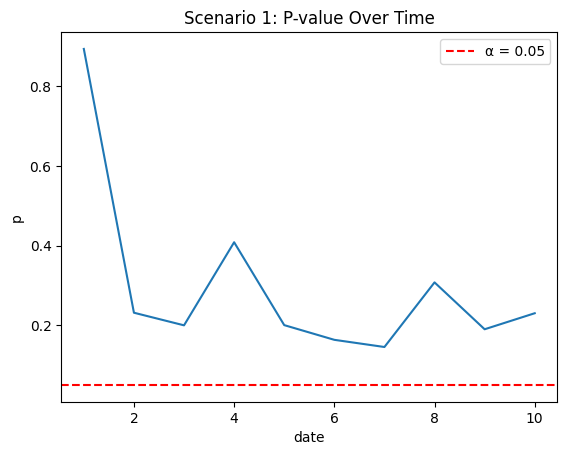

In [71]:
# P-value trajectory — does it cross the significance threshold?
ax = sns.lineplot(data=stat_result, x='date', y='p')
ax.axhline(0.05, ls='--', color='red', label='α = 0.05')
ax.legend()
ax.set_title('Scenario 1: P-value Over Time')
# With only a 0.5-unit difference, 10 days may not be enough to stabilize

## Scenario 2: No True Effect (μ_control = μ_experiment)

Both groups are drawn from identical distributions. Any statistically significant result here is a **false positive**.
Running for 100 days illustrates the risk of peeking and stopping early.

In [84]:
days = 100

mu_control,    sigma_control,    n_control    = 100, 20, 100
mu_experiment, sigma_experiment, n_experiment = 100, 20, 100

current_date = 1
user_data    = pd.DataFrame()
stat_result  = pd.DataFrame()
daily_data   = pd.DataFrame()

In [85]:
for day in range(days):
    daily_data_control    = np.random.normal(mu_control,    sigma_control,    n_control)
    daily_data_experiment = np.random.normal(mu_experiment, sigma_experiment, n_experiment)

    day_data_control            = pd.DataFrame({'value': daily_data_control})
    day_data_control['date']    = current_date
    day_data_control['group']   = 'control'

    day_data_experiment           = pd.DataFrame({'value': daily_data_experiment})
    day_data_experiment['date']   = current_date
    day_data_experiment['group']  = 'experiment'

    user_data = pd.concat([user_data, day_data_control, day_data_experiment], ignore_index=True)

    fit = stats.ttest_ind(
        user_data[user_data.group == 'control'].value,
        user_data[user_data.group == 'experiment'].value
    )
    stat_result = pd.concat([
        stat_result,
        pd.DataFrame({'t': [fit[0]], 'p': [fit[1]], 'date': current_date})
    ])

    current_data_stat         = user_data.groupby('group').agg({'value': 'mean'})
    current_data_stat['date'] = current_date
    daily_data = pd.concat([daily_data, current_data_stat])

    current_date += 1

Text(0.5, 1.0, 'Scenario 2: Cumulative Mean by Group (No True Effect)')

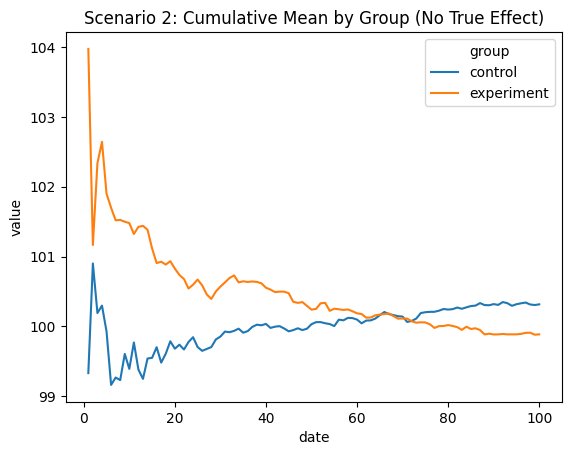

In [86]:
ax = sns.lineplot(data=daily_data, x='date', y='value', hue='group')
ax.set_title('Scenario 2: Cumulative Mean by Group (No True Effect)')

Text(0.5, 1.0, 'Scenario 2: P-value Over Time (No True Effect)')

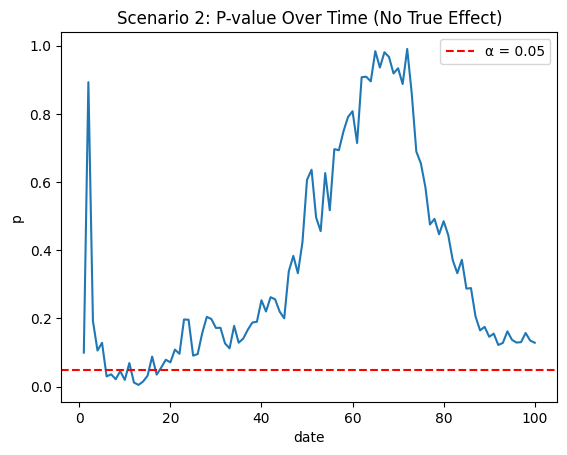

In [87]:
ax = sns.lineplot(data=stat_result, x='date', y='p')
ax.axhline(0.05, ls='--', color='red', label='α = 0.05')
ax.legend()
ax.set_title('Scenario 2: P-value Over Time (No True Effect)')
# The p-value may randomly dip below 0.05 — this is the false positive risk

## Key Takeaways

### When to stop a test
- **Never stop the moment the p-value crosses 0.05** — it fluctuates and early crossings are often noise.
- The p-value needs time to stabilize. In Scenario 1, a trend typically stabilizes around day 60 with these parameters.
- The right stopping point is determined empirically using company historical data.

### Determining sample size and test duration

**Method 1 — By the book (MDE approach):**
- Collect two samples with known means and standard deviations.
- Use statistical power analysis to compute the required sample size (see `11_test_power.ipynb`).
- Many online calculators automate this.
- **Caveat:** Requires assumptions (normality, known effect size) that rarely hold perfectly in practice.

**Method 2 — Empirical (used in practice):**
- Leverage the company's historical A/B test results to calibrate expectations.
- Industry rule of thumb: if no signal after N days, the true effect is likely too small to matter (cost of running longer > benefit of detecting it).
- If it's the company's first A/B test, calculators won't help — observe the p-value trajectory live and build intuition over time.